In [10]:
# 데이터 처리를 위한 pandas와 numpy를 불러옵니다.
import pandas as pd
import numpy as np

# 그래프를 그리기 위한 matplotlib와 seaborn을 불러옵니다.
import matplotlib.pyplot as plt
import seaborn as sns

# 파일과 폴더를 확인하기 위해 os를 불러옵니다.
import os

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 결과 저장 폴더 생성
os.makedirs("../images", exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)


In [11]:
# 공통 전처리 데이터
violation_file = "../data/processed/violation_2017_2023.csv"

# 05에서 만든 동별 민원/CCTV/상습 발생지 데이터
support_file = "../data/processed/dong_support_summary.csv"

# 2020 불법주차 좌표 데이터
parking_2020_file = "../data/대구광역시 북구_데이터통합플랫폼_불법주차_20201005.csv"

# 04에서 만든 장소 TOP10 요약 데이터
location_top10_file = "../data/processed/location_top10_summary.csv"

# 파일을 불러옵니다.
violation = pd.read_csv(
    violation_file,
    encoding="utf-8-sig",
    parse_dates=["위반일자"]
)

support = pd.read_csv(
    support_file,
    encoding="utf-8-sig"
)

parking_2020 = pd.read_csv(
    parking_2020_file,
    encoding="utf-8"
)

print("2017~2023 단속 데이터:", violation.shape)
print("동별 지원 데이터:", support.shape)
print("2020 좌표 데이터:", parking_2020.shape)

# 04 분석 결과가 있으면 함께 불러옵니다.
if os.path.exists(location_top10_file):
    location_top10 = pd.read_csv(location_top10_file, encoding="utf-8-sig")
    print("장소 TOP10 요약:", location_top10.shape)
else:
    location_top10 = None
    print("※ location_top10_summary.csv가 없습니다. 04_location_analysis.ipynb를 먼저 실행하세요.")

# 대표 좌표가 없는 동을 보완할 자료를 불러옵니다.
complaint = pd.read_csv(
    "../data/processed/lee_complaint_2018_2021.csv", encoding="utf-8-sig"
)
cctv = pd.read_csv(
    "../data/processed/lee_cctv_location.csv", encoding="utf-8-sig"
)
hotspot = pd.read_csv(
    "../data/processed/hotspot_clean.csv", encoding="utf-8-sig"
)

print("민원 좌표 데이터:", complaint.shape)
print("CCTV 좌표 데이터:", cctv.shape)
print("상습 발생지 좌표 데이터:", hotspot.shape)


2017~2023 단속 데이터: (681828, 10)
동별 지원 데이터: (26, 6)
2020 좌표 데이터: (67949, 5)
장소 TOP10 요약: (10, 6)
민원 좌표 데이터: (14672, 7)
CCTV 좌표 데이터: (719, 9)
상습 발생지 좌표 데이터: (25, 11)


In [12]:
# 위반장소 앞뒤 공백을 정리합니다.
violation["위반장소_정리"] = violation["위반장소"].astype(str).str.strip()
violation["위반장소_정리"] = violation["위반장소_정리"].str.replace(r"\s+", " ", regex=True)

# 지원자료와 2020 자료에서 확인된 동 이름만 추출합니다.
# '자동차', '부동산' 등의 문구와 오타를 별도의 동으로 집계하지 않습니다.
known_dongs = set(support["동"].dropna()) | set(
    parking_2020["행정동"].dropna().str.strip().str.replace(
        r"\d+(?=동)", "", regex=True
    )
)
dong_names = sorted(
    {name[:-1] for name in known_dongs if name.endswith("동")},
    key=lambda name: (-len(name), name)
)
dong_extract = violation["위반장소_정리"].str.extract(
    r"(" + "|".join(dong_names) + r")\d*(동)(?:\d가)?"
)

violation["동"] = dong_extract[0] + dong_extract[1]

# 추출 결과 확인
matched = violation["동"].notnull().sum()
total = len(violation)
coverage = matched / total * 100

print("전체 단속 건수:", f"{total:,}")
print("동 이름 추출 성공:", f"{matched:,}")
print("동 추출 가능 비율:", f"{coverage:.1f}%")
print()
print("추출된 동 상위 20개")
print(violation["동"].value_counts().head(20))


전체 단속 건수: 681,828
동 이름 추출 성공: 437,697
동 추출 가능 비율: 64.2%

추출된 동 상위 20개
동
동천동    66091
산격동    52650
태전동    36495
침산동    35722
칠성동    28339
복현동    23689
읍내동    22792
관음동    20653
구암동    20431
서변동    19383
학정동    17132
고성동    15528
사수동    13577
노원동    13504
대현동    12122
매천동     8596
동변동     7276
연경동     6854
팔달동     4273
국우동     4207
Name: count, dtype: int64


In [13]:
# 동을 추출할 수 있는 데이터만 사용합니다.
v = violation.dropna(subset=["동"]).copy()

# 동별 전체 단속 건수
violation_by_dong = (
    v.groupby("동")
    .size()
    .rename("단속건수_2017_2023")
)

# 동 × 시간 교차표
dong_hour = pd.crosstab(v["동"], v["시간"]).reindex(columns=range(24), fill_value=0)

# 동별 집중 시간
peak_hour = dong_hour.idxmax(axis=1).rename("집중시간")
peak_hour_count = dong_hour.max(axis=1).rename("집중시간건수")

# 동별 집중시간 비중
hour_concentration = (
    peak_hour_count / violation_by_dong * 100
).round(1).rename("집중시간비중")

# 동 × 요일 교차표
weekday_order = [
    "월요일", "화요일", "수요일", "목요일",
    "금요일", "토요일", "일요일"
]

dong_weekday = pd.crosstab(v["동"], v["요일"]).reindex(
    columns=weekday_order,
    fill_value=0
)

# 동별 집중 요일
peak_weekday = dong_weekday.idxmax(axis=1).rename("집중요일")
peak_weekday_count = dong_weekday.max(axis=1).rename("집중요일건수")

# 동별 요일 집중 비중
weekday_concentration = (
    peak_weekday_count / violation_by_dong * 100
).round(1).rename("집중요일비중")

# 한 표로 합칩니다.
violation_dong_summary = pd.concat(
    [
        violation_by_dong,
        peak_hour,
        peak_hour_count,
        hour_concentration,
        peak_weekday,
        peak_weekday_count,
        weekday_concentration
    ],
    axis=1
).reset_index()

display(violation_dong_summary.head(20))


,동,단속건수_2017_2023,집중시간,집중시간건수,집중시간비중,집중요일,집중요일건수,집중요일비중
0,검단동,4065,15,568,14.0,목요일,963,23.7
1,고성동,15528,14,3607,23.2,월요일,3300,21.3
2,관음동,20653,15,3887,18.8,화요일,4017,19.4
3,구암동,20431,7,4003,19.6,월요일,4104,20.1
4,국우동,4207,7,705,16.8,목요일,942,22.4
5,금호동,1324,14,183,13.8,월요일,269,20.3
6,노곡동,296,12,93,31.4,월요일,52,17.6
7,노원동,13504,15,2024,15.0,금요일,2505,18.6
8,대현동,12122,14,1806,14.9,월요일,2707,22.3
9,동변동,7276,7,1617,22.2,화요일,1865,25.6


In [14]:
# 위도·경도 컬럼이 뒤바뀐 자료는 중앙값으로 확인해 보정합니다.
def fix_lat_lon(df, lat_col="위도", lon_col="경도"):
    result = df.copy()
    result[lat_col] = pd.to_numeric(result[lat_col], errors="coerce")
    result[lon_col] = pd.to_numeric(result[lon_col], errors="coerce")

    lat_median = result[lat_col].median()
    lon_median = result[lon_col].median()
    if pd.notna(lat_median) and pd.notna(lon_median):
        if lat_median > 90 and 0 < lon_median < 90:
            result[[lat_col, lon_col]] = result[[lon_col, lat_col]].to_numpy()

    # 유효하지 않은 좌표는 평균 계산과 지도 표시에서 제외합니다.
    valid = (
        result[lat_col].between(-90, 90)
        & result[lon_col].between(-180, 180)
    )
    result.loc[~valid, [lat_col, lon_col]] = np.nan
    return result


def summarize_coordinates(df, dong_col, source_name):
    data = fix_lat_lon(df)
    # 단속·지원 데이터와 동일하게 산격3동→산격동, 칠성동2가→칠성동으로 맞춥니다.
    dong = data[dong_col].astype("string").str.strip().str.extract(
        r"([가-힣]+?)\d*(동)(?:\d가)?"
    )
    data["동"] = dong[0] + dong[1]
    summary = (
        data.dropna(subset=["동", "위도", "경도"])
        .groupby("동", as_index=False)
        .agg(대표위도=("위도", "mean"), 대표경도=("경도", "mean"))
    )
    summary["좌표출처"] = source_name
    return summary


# 자료 순서가 좌표 채우기 우선순위입니다.
coordinate_sources = [
    summarize_coordinates(parking_2020, "행정동", "2020 불법주차"),
    summarize_coordinates(complaint, "동", "민원"),
    summarize_coordinates(cctv, "동", "CCTV"),
    summarize_coordinates(hotspot, "동", "상습 발생지"),
]

# 동마다 가장 먼저 확보된 유효한 위도·경도 쌍과 출처를 함께 사용합니다.
preferred_coordinates = (
    pd.concat(coordinate_sources, ignore_index=True)
    .drop_duplicates(subset=["동"], keep="first")
)
all_dongs = sorted(
    set(violation_dong_summary["동"].dropna()) | set(support["동"].dropna())
)
dong_coord = pd.DataFrame({"동": all_dongs}).merge(
    preferred_coordinates, on="동", how="left", validate="one_to_one"
)
dong_coord["지도표시가능"] = dong_coord[["대표위도", "대표경도"]].notna().all(axis=1)

print("전체 분석 동 수:", len(dong_coord))
print("좌표 확보 동 수:", int(dong_coord["지도표시가능"].sum()))
print("좌표 미확보 동:", dong_coord.loc[~dong_coord["지도표시가능"], "동"].tolist())
print("좌표 출처별 동 수:")
print(dong_coord["좌표출처"].value_counts())
display(dong_coord)


전체 분석 동 수: 27
좌표 확보 동 수: 27
좌표 미확보 동: []
좌표 출처별 동 수:
좌표출처
2020 불법주차    15
민원           12
Name: count, dtype: int64


,동,대표위도,대표경도,좌표출처,지도표시가능
0,검단동,35.913265,128.622055,2020 불법주차,True
1,고성동,35.881457,128.584430,2020 불법주차,True
2,관음동,35.940417,128.545319,2020 불법주차,True
3,구암동,35.932598,128.561487,2020 불법주차,True
4,국우동,35.949053,128.570808,2020 불법주차,True
5,금호동,35.894260,128.521473,민원,True
6,노곡동,35.904170,128.561719,민원,True
7,노원동,35.894453,128.570073,2020 불법주차,True
8,대현동,35.883331,128.607220,2020 불법주차,True
9,도남동,35.961073,128.583888,민원,True


In [15]:
# 단속 분석 결과와 05의 지원 데이터를 합칩니다.
final = violation_dong_summary.merge(
    support,
    on="동",
    how="outer"
)

# 지도 표시용 대표 좌표를 붙입니다.
final = final.merge(
    dong_coord,
    on="동",
    how="left"
)

# 수치형 결측치는 0으로 채웁니다.
zero_cols = [
    "단속건수_2017_2023",
    "집중시간건수",
    "집중시간비중",
    "집중요일건수",
    "집중요일비중",
    "민원건수_2018_2021",
    "CCTV수",
    "주정차단속CCTV수",
    "상습발생지수",
    "상습지역민원누적"
]

for col in zero_cols:
    if col in final.columns:
        final[col] = final[col].fillna(0)

# 단속이 하나도 없는 동은 집중시간/요일을 '자료없음'으로 표시합니다.
final["집중시간"] = final["집중시간"].fillna(-1).astype(int)
final["집중요일"] = final["집중요일"].fillna("자료없음")

# 대표 좌표를 확보한 동만 지도에 표시합니다.
final["지도표시가능"] = final["지도표시가능"].fillna(False).astype(bool)

# 단속건수 기준으로 정렬합니다.
final = final.sort_values(
    "단속건수_2017_2023",
    ascending=False
).reset_index(drop=True)

display(final.head(20))


,동,단속건수_2017_2023,집중시간,집중시간건수,집중시간비중,집중요일,집중요일건수,집중요일비중,민원건수_2018_2021,CCTV수,주정차단속CCTV수,상습발생지수,상습지역민원누적,대표위도,대표경도,좌표출처,지도표시가능
0,동천동,66091.0,15,14572.0,22.0,월요일,11659.0,17.6,8869.0,44.0,6.0,3.0,1249.0,35.939396,128.558542,2020 불법주차,True
1,산격동,52650.0,15,8039.0,15.3,수요일,9026.0,17.1,10961.0,80.0,12.0,5.0,793.0,35.900253,128.605982,2020 불법주차,True
2,태전동,36495.0,15,5485.0,15.0,월요일,7069.0,19.4,6098.0,78.0,9.0,1.0,289.0,35.922805,128.546762,2020 불법주차,True
3,침산동,35722.0,14,4915.0,13.8,월요일,6663.0,18.7,5297.0,51.0,6.0,0.0,0.0,35.894867,128.586799,2020 불법주차,True
4,칠성동,28339.0,15,5192.0,18.3,수요일,5343.0,18.9,3847.0,45.0,12.0,0.0,0.0,35.878536,128.597066,2020 불법주차,True
5,복현동,23689.0,15,3226.0,13.6,목요일,5111.0,21.6,7303.0,52.0,4.0,2.0,2084.0,35.896808,128.619770,2020 불법주차,True
6,읍내동,22792.0,15,4681.0,20.5,수요일,4622.0,20.3,4217.0,61.0,3.0,1.0,211.0,35.943041,128.551989,2020 불법주차,True
7,관음동,20653.0,15,3887.0,18.8,화요일,4017.0,19.4,4924.0,34.0,2.0,0.0,0.0,35.940417,128.545319,2020 불법주차,True
8,구암동,20431.0,7,4003.0,19.6,월요일,4104.0,20.1,6635.0,63.0,5.0,3.0,1114.0,35.932598,128.561487,2020 불법주차,True
9,서변동,19383.0,8,2991.0,15.4,금요일,4883.0,25.2,3592.0,26.0,4.0,2.0,816.0,35.922236,128.596603,민원,True


In [16]:
# 상대 순위를 0~1 범위로 계산하는 함수입니다.
def percentile_score(series):
    return series.rank(pct=True, method="average")

# 단속 발생량 점수 (40점)
final["단속점수"] = (
    percentile_score(final["단속건수_2017_2023"]) * 40
)

# 민원 발생량 점수 (25점)
final["민원점수"] = (
    percentile_score(final["민원건수_2018_2021"]) * 25
)

# 특정 시간 집중도 점수 (20점)
final["시간집중점수"] = (
    percentile_score(final["집중시간비중"]) * 20
)

# CCTV는 적을수록 부족도 점수가 높게 계산되도록 반대로 순위를 적용합니다.
cctv_rank = percentile_score(final["주정차단속CCTV수"])
final["CCTV부족점수"] = (1 - cctv_rank) * 15

# 전체 관리 우선도 점수
final["관리점수"] = (
    final["단속점수"]
    + final["민원점수"]
    + final["시간집중점수"]
    + final["CCTV부족점수"]
).round(1)

display(
    final[
        [
            "동", "단속점수", "민원점수",
            "시간집중점수", "CCTV부족점수", "관리점수"
        ]
    ].sort_values("관리점수", ascending=False)
)


,동,단속점수,민원점수,시간집중점수,CCTV부족점수,관리점수
0,동천동,40.000000,24.074074,12.592593,1.944444,78.6
1,산격동,38.518519,25.000000,7.407407,0.277778,71.2
6,읍내동,31.111111,17.592593,11.851852,6.111111,66.7
7,관음동,29.629630,18.518519,10.370370,7.500000,66.0
2,태전동,37.037037,21.296296,6.296296,1.111111,65.7
8,구암동,28.148148,22.222222,11.111111,3.611111,65.1
10,학정동,25.185185,13.888889,17.777778,7.500000,64.4
5,복현동,32.592593,23.148148,1.481481,5.277778,62.5
4,칠성동,34.074074,16.666667,9.629630,0.277778,60.6
3,침산동,35.555556,20.370370,2.592593,1.944444,60.5


In [17]:
# 관리점수의 상대 백분위를 계산합니다.
final["관리점수백분위"] = (
    final["관리점수"]
    .rank(pct=True, method="average")
    * 100
).round(1)

# 상대 백분위를 기준으로 등급 부여
def make_grade(percentile):
    if percentile >= 80:
        return "A"
    elif percentile >= 60:
        return "B"
    elif percentile >= 30:
        return "C"
    else:
        return "D"

final["관리등급"] = final["관리점수백분위"].apply(make_grade)

print("등급별 지역 수")
print(final["관리등급"].value_counts().sort_index())

# 주정차단속 CCTV 수의 중앙값을 기준으로 상대적으로 적고 많음을 구분합니다.
cctv_median = final["주정차단속CCTV수"].median()

def management_type(row):
    if row["관리등급"] == "A":
        if row["주정차단속CCTV수"] <= cctv_median:
            return "CCTV 보강·집중단속 검토"
        else:
            return "집중시간대 단속 강화 검토"

    elif row["관리등급"] == "B":
        if row["주정차단속CCTV수"] <= cctv_median:
            return "단속 인프라 보강 검토"
        else:
            return "관리 강화 검토"

    elif row["관리등급"] == "C":
        return "일반 관리"

    else:
        return "상대적 우선도 낮음"

final["관리유형"] = final.apply(
    management_type,
    axis=1
)

# 집중시간 표시용 문자열
def peak_hour_text(hour):
    return "자료없음" if hour < 0 else f"{int(hour)}시"

final["집중시간표시"] = final["집중시간"].apply(
    peak_hour_text
)

display(
    final[
        [
            "동",
            "관리점수",
            "관리점수백분위",
            "관리등급",
            "관리유형",
            "단속건수_2017_2023",
            "민원건수_2018_2021",
            "주정차단속CCTV수",
            "집중요일",
            "집중시간표시",
            "좌표출처",
            "지도표시가능"
        ]
    ].sort_values("관리점수", ascending=False)
)


등급별 지역 수
관리등급
A    6
B    6
C    7
D    8
Name: count, dtype: int64


,동,관리점수,관리점수백분위,관리등급,관리유형,단속건수_2017_2023,민원건수_2018_2021,주정차단속CCTV수,집중요일,집중시간표시,좌표출처,지도표시가능
0,동천동,78.6,100.0,A,집중시간대 단속 강화 검토,66091.0,8869.0,6.0,월요일,15시,2020 불법주차,True
1,산격동,71.2,96.3,A,집중시간대 단속 강화 검토,52650.0,10961.0,12.0,수요일,15시,2020 불법주차,True
6,읍내동,66.7,92.6,A,집중시간대 단속 강화 검토,22792.0,4217.0,3.0,수요일,15시,2020 불법주차,True
7,관음동,66.0,88.9,A,CCTV 보강·집중단속 검토,20653.0,4924.0,2.0,화요일,15시,2020 불법주차,True
2,태전동,65.7,85.2,A,집중시간대 단속 강화 검토,36495.0,6098.0,9.0,월요일,15시,2020 불법주차,True
8,구암동,65.1,81.5,A,집중시간대 단속 강화 검토,20431.0,6635.0,5.0,월요일,7시,2020 불법주차,True
10,학정동,64.4,77.8,B,단속 인프라 보강 검토,17132.0,2002.0,2.0,월요일,11시,민원,True
5,복현동,62.5,74.1,B,관리 강화 검토,23689.0,7303.0,4.0,목요일,15시,2020 불법주차,True
4,칠성동,60.6,70.4,B,관리 강화 검토,28339.0,3847.0,12.0,수요일,15시,2020 불법주차,True
3,침산동,60.5,66.7,B,관리 강화 검토,35722.0,5297.0,6.0,월요일,14시,2020 불법주차,True


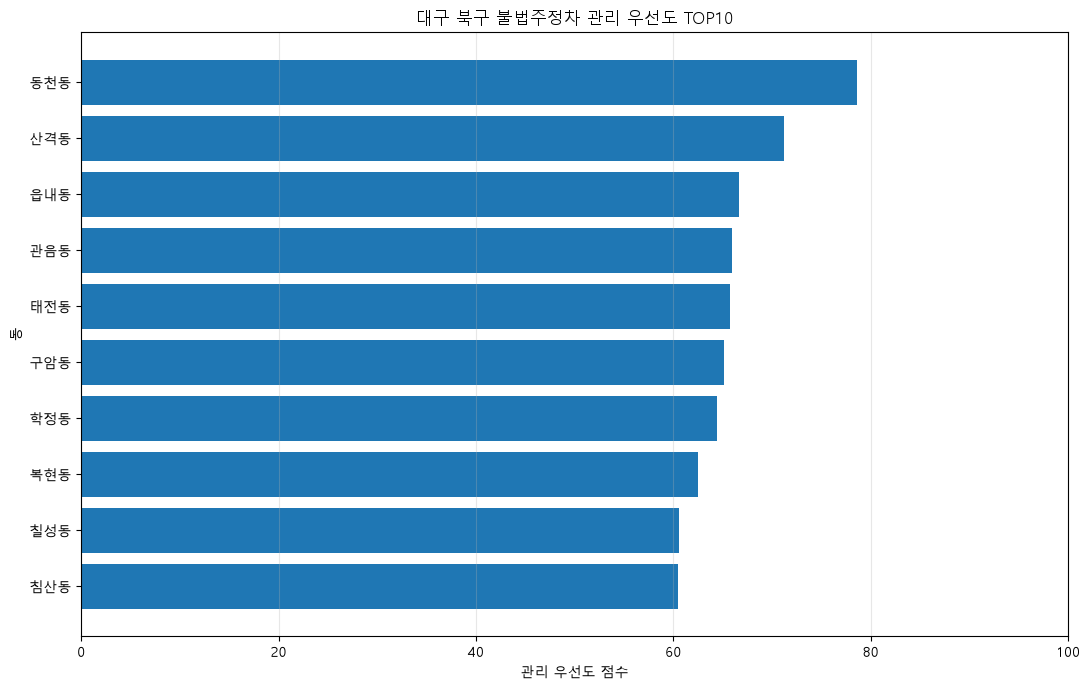

In [18]:
# 관리점수 상위 10개 동을 선택합니다.
priority_top10 = (
    final.sort_values("관리점수", ascending=False)
    .head(10)
)

plt.figure(figsize=(11, 7))
plt.barh(
    priority_top10["동"],
    priority_top10["관리점수"]
)
plt.gca().invert_yaxis()

plt.title("대구 북구 불법주정차 관리 우선도 TOP10")
plt.xlabel("관리 우선도 점수")
plt.ylabel("동")
plt.xlim(0, 100)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()

plt.savefig("../images/final_priority_top10.png", dpi=150, bbox_inches="tight")
plt.show()


## 11. 관리등급 분포

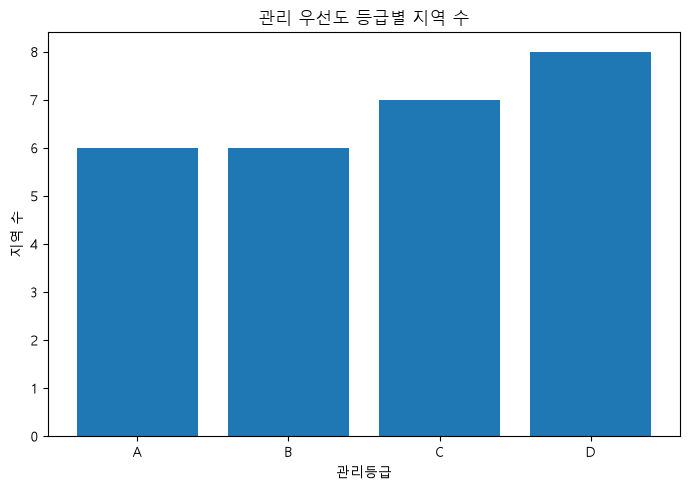

관리등급
A    6
B    6
C    7
D    8
Name: count, dtype: int64


In [19]:
grade_order = ["A", "B", "C", "D"]

grade_count = (
    final["관리등급"]
    .value_counts()
    .reindex(grade_order, fill_value=0)
)

plt.figure(figsize=(7, 5))
plt.bar(
    grade_count.index,
    grade_count.values
)

plt.title("관리 우선도 등급별 지역 수")
plt.xlabel("관리등급")
plt.ylabel("지역 수")
plt.tight_layout()

plt.savefig(
    "../images/final_grade_count.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print(grade_count)


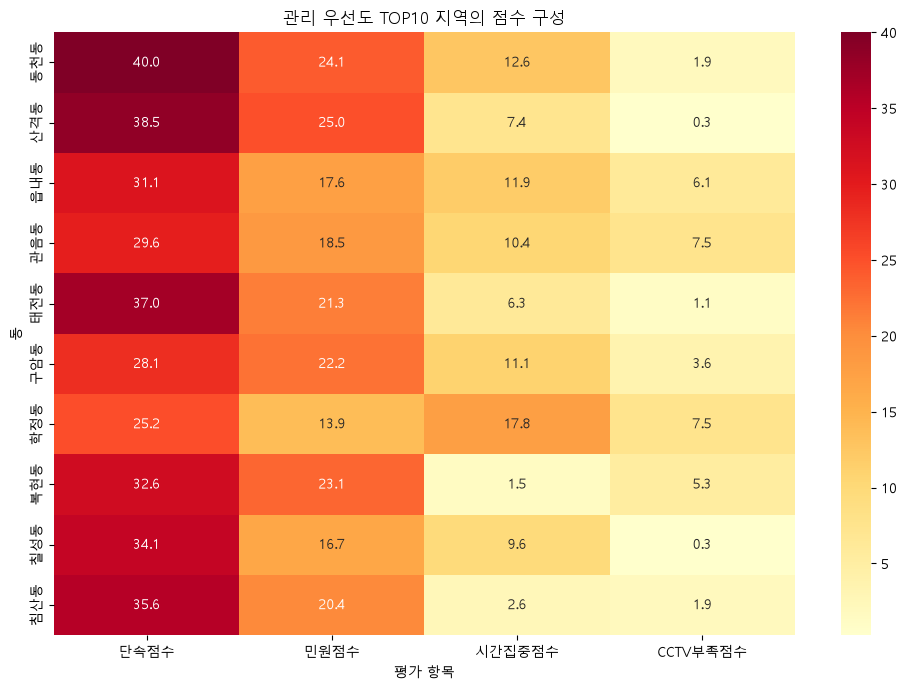

In [20]:
# 상위 10개 지역의 점수 구성요소를 확인합니다.
score_cols = [
    "단속점수",
    "민원점수",
    "시간집중점수",
    "CCTV부족점수"
]

score_heatmap = priority_top10.set_index("동")[score_cols]

plt.figure(figsize=(10, 7))
sns.heatmap(
    score_heatmap,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd"
)

plt.title("관리 우선도 TOP10 지역의 점수 구성")
plt.xlabel("평가 항목")
plt.ylabel("동")
plt.tight_layout()

plt.savefig("../images/final_priority_score_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


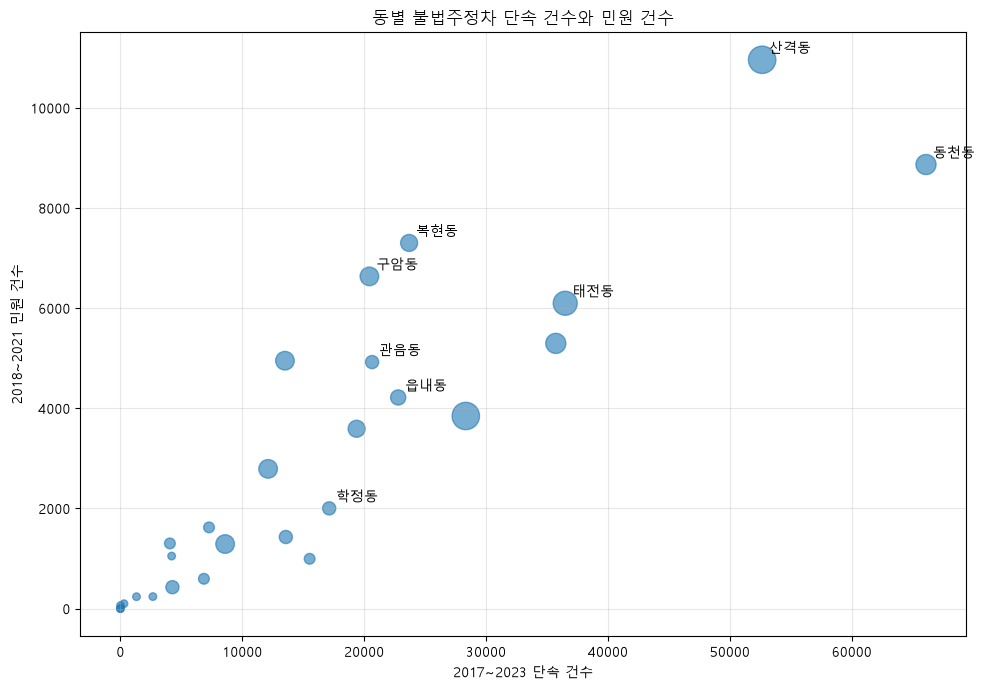

In [21]:
plt.figure(figsize=(10, 7))

bubble_size = final["주정차단속CCTV수"] * 30 + 30

plt.scatter(
    final["단속건수_2017_2023"],
    final["민원건수_2018_2021"],
    s=bubble_size,
    alpha=0.6
)

# 관리점수 상위 8개 동만 이름 표시
for _, row in final.sort_values("관리점수", ascending=False).head(8).iterrows():
    plt.annotate(
        row["동"],
        (row["단속건수_2017_2023"], row["민원건수_2018_2021"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.title("동별 불법주정차 단속 건수와 민원 건수")
plt.xlabel("2017~2023 단속 건수")
plt.ylabel("2018~2021 민원 건수")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("../images/final_violation_complaint_scatter.png", dpi=150, bbox_inches="tight")
plt.show()


In [22]:
# 전체 연도, 월, 요일, 시간 집계
year_count = violation.groupby("연도").size()
month_count = violation.groupby("월").size().reindex(range(1, 13))
weekday_order = [
    "월요일", "화요일", "수요일", "목요일",
    "금요일", "토요일", "일요일"
]
weekday_count = violation.groupby("요일").size().reindex(weekday_order)
hour_count = violation.groupby("시간").size().reindex(range(24), fill_value=0)

overall_summary = pd.DataFrame([{
    "전체단속건수": len(violation),
    "분석시작일": violation["위반일자"].min().date(),
    "분석종료일": violation["위반일자"].max().date(),
    "최다연도": int(year_count.idxmax()),
    "최다월": int(month_count.idxmax()),
    "최다요일": weekday_count.idxmax(),
    "최다시간": int(hour_count.idxmax()),
    "최다시간건수": int(hour_count.max()),
    "동추출가능비율": round(coverage, 1),
    "지도표시가능동수": int(final["지도표시가능"].sum()),
    "전체분석동수": int(len(final))
}])

# 04 결과가 있으면 TOP1 장소도 추가합니다.
if location_top10 is not None and len(location_top10) > 0:
    overall_summary["최다단속장소"] = location_top10.iloc[0]["위반장소"]
    overall_summary["최다단속장소건수"] = int(location_top10.iloc[0]["총단속건수"])

display(overall_summary)



,전체단속건수,분석시작일,분석종료일,최다연도,최다월,최다요일,최다시간,최다시간건수,동추출가능비율,지도표시가능동수,전체분석동수,최다단속장소,최다단속장소건수
0,681828,2017-01-01,2023-12-31,2023,11,월요일,15,114933,64.2,27,27,동아아울렛 뒤편,17189


In [23]:
# 웹에서 사용할 컬럼을 정리합니다.
dashboard_cols = [
    "동",
    "대표위도",
    "대표경도",
    "좌표출처",
    "지도표시가능",
    "단속건수_2017_2023",
    "민원건수_2018_2021",
    "CCTV수",
    "주정차단속CCTV수",
    "상습발생지수",
    "상습지역민원누적",
    "집중요일",
    "집중요일비중",
    "집중시간",
    "집중시간비중",
    "단속점수",
    "민원점수",
    "시간집중점수",
    "CCTV부족점수",
    "관리점수",
    "관리점수백분위",
    "관리등급",
    "관리유형"
]

dashboard_region = final[dashboard_cols].copy()

# 관리점수 순으로 정렬합니다.
dashboard_region = dashboard_region.sort_values(
    "관리점수",
    ascending=False
).reset_index(drop=True)

# 저장
region_path = "../data/processed/final_region_summary.csv"
overall_path = "../data/processed/final_overall_summary.csv"

dashboard_region.to_csv(
    region_path,
    index=False,
    encoding="utf-8-sig"
)

overall_summary.to_csv(
    overall_path,
    index=False,
    encoding="utf-8-sig"
)

print("저장 완료:", region_path)
print("저장 완료:", overall_path)


저장 완료: ../data/processed/final_region_summary.csv
저장 완료: ../data/processed/final_overall_summary.csv


In [24]:
# 관리 우선도 상위 지역을 최종 확인합니다.
final_view = dashboard_region.head(10).copy()

display(final_view)

print("관리 우선도 1위:", final_view.iloc[0]["동"])
print("관리점수:", final_view.iloc[0]["관리점수"])
print("등급:", final_view.iloc[0]["관리등급"])
print("집중요일:", final_view.iloc[0]["집중요일"])
print("집중시간:", peak_hour_text(final_view.iloc[0]["집중시간"]))
print("관리유형:", final_view.iloc[0]["관리유형"])


,동,대표위도,대표경도,좌표출처,지도표시가능,단속건수_2017_2023,민원건수_2018_2021,CCTV수,주정차단속CCTV수,상습발생지수,...,집중시간,집중시간비중,단속점수,민원점수,시간집중점수,CCTV부족점수,관리점수,관리점수백분위,관리등급,관리유형
0,동천동,35.939396,128.558542,2020 불법주차,True,66091.0,8869.0,44.0,6.0,3.0,...,15,22.0,40.000000,24.074074,12.592593,1.944444,78.6,100.0,A,집중시간대 단속 강화 검토
1,산격동,35.900253,128.605982,2020 불법주차,True,52650.0,10961.0,80.0,12.0,5.0,...,15,15.3,38.518519,25.000000,7.407407,0.277778,71.2,96.3,A,집중시간대 단속 강화 검토
2,읍내동,35.943041,128.551989,2020 불법주차,True,22792.0,4217.0,61.0,3.0,1.0,...,15,20.5,31.111111,17.592593,11.851852,6.111111,66.7,92.6,A,집중시간대 단속 강화 검토
3,관음동,35.940417,128.545319,2020 불법주차,True,20653.0,4924.0,34.0,2.0,0.0,...,15,18.8,29.629630,18.518519,10.370370,7.500000,66.0,88.9,A,CCTV 보강·집중단속 검토
4,태전동,35.922805,128.546762,2020 불법주차,True,36495.0,6098.0,78.0,9.0,1.0,...,15,15.0,37.037037,21.296296,6.296296,1.111111,65.7,85.2,A,집중시간대 단속 강화 검토
5,구암동,35.932598,128.561487,2020 불법주차,True,20431.0,6635.0,63.0,5.0,3.0,...,7,19.6,28.148148,22.222222,11.111111,3.611111,65.1,81.5,A,집중시간대 단속 강화 검토
6,학정동,35.951207,128.566310,민원,True,17132.0,2002.0,24.0,2.0,1.0,...,11,31.8,25.185185,13.888889,17.777778,7.500000,64.4,77.8,B,단속 인프라 보강 검토
7,복현동,35.896808,128.619770,2020 불법주차,True,23689.0,7303.0,52.0,4.0,2.0,...,15,13.6,32.592593,23.148148,1.481481,5.277778,62.5,74.1,B,관리 강화 검토
8,칠성동,35.878536,128.597066,2020 불법주차,True,28339.0,3847.0,45.0,12.0,0.0,...,15,18.3,34.074074,16.666667,9.629630,0.277778,60.6,70.4,B,관리 강화 검토
9,침산동,35.894867,128.586799,2020 불법주차,True,35722.0,5297.0,51.0,6.0,0.0,...,14,13.8,35.555556,20.370370,2.592593,1.944444,60.5,66.7,B,관리 강화 검토


관리 우선도 1위: 동천동
관리점수: 78.6
등급: A
집중요일: 월요일
집중시간: 15시
관리유형: 집중시간대 단속 강화 검토


In [25]:
# 지도 표시 가능 여부 확인
print("전체 분석 동 수:", len(dashboard_region))
print(
    "지도 표시 가능 동 수:",
    dashboard_region["지도표시가능"].sum()
)
print(
    "지도 표시 불가능 동 수:",
    (~dashboard_region["지도표시가능"]).sum()
)

print()
print("관리등급 분포")
print(
    dashboard_region["관리등급"]
    .value_counts()
    .reindex(["A", "B", "C", "D"], fill_value=0)
)

print()
print("관리 우선도 상위 10개 지역")
display(
    dashboard_region[
        [
            "동",
            "관리점수",
            "관리점수백분위",
            "관리등급",
            "관리유형",
            "집중요일",
            "집중시간",
            "대표위도",
            "대표경도",
            "좌표출처"
        ]
    ].head(10)
)

# 좌표가 아직 없는 지역 확인
missing_coord = dashboard_region[
    ~dashboard_region["지도표시가능"]
]

if len(missing_coord) > 0:
    print()
    print("※ 아직 대표 좌표가 없는 지역")
    print(missing_coord["동"].tolist())
else:
    print()
    print("모든 분석 지역의 대표 좌표가 확보되었습니다.")


전체 분석 동 수: 27
지도 표시 가능 동 수: 27
지도 표시 불가능 동 수: 0

관리등급 분포
관리등급
A    6
B    6
C    7
D    8
Name: count, dtype: int64

관리 우선도 상위 10개 지역


,동,관리점수,관리점수백분위,관리등급,관리유형,집중요일,집중시간,대표위도,대표경도,좌표출처
0,동천동,78.6,100.0,A,집중시간대 단속 강화 검토,월요일,15,35.939396,128.558542,2020 불법주차
1,산격동,71.2,96.3,A,집중시간대 단속 강화 검토,수요일,15,35.900253,128.605982,2020 불법주차
2,읍내동,66.7,92.6,A,집중시간대 단속 강화 검토,수요일,15,35.943041,128.551989,2020 불법주차
3,관음동,66.0,88.9,A,CCTV 보강·집중단속 검토,화요일,15,35.940417,128.545319,2020 불법주차
4,태전동,65.7,85.2,A,집중시간대 단속 강화 검토,월요일,15,35.922805,128.546762,2020 불법주차
5,구암동,65.1,81.5,A,집중시간대 단속 강화 검토,월요일,7,35.932598,128.561487,2020 불법주차
6,학정동,64.4,77.8,B,단속 인프라 보강 검토,월요일,11,35.951207,128.566310,민원
7,복현동,62.5,74.1,B,관리 강화 검토,목요일,15,35.896808,128.619770,2020 불법주차
8,칠성동,60.6,70.4,B,관리 강화 검토,수요일,15,35.878536,128.597066,2020 불법주차
9,침산동,60.5,66.7,B,관리 강화 검토,월요일,14,35.894867,128.586799,2020 불법주차



모든 분석 지역의 대표 좌표가 확보되었습니다.


## 16. 해석 시 주의사항

1. **관리등급은 프로젝트 내부 상대등급**입니다.
2. 단속자료는 2017~2023, 민원자료는 2018~2021, CCTV 자료는 2020~2021로 기준기간이 다릅니다.
3. 단속자료의 동 정보는 위반장소 문자열에서 추출했으며, 전체 단속 중 일부는 동을 식별할 수 없습니다.
4. 대표 좌표는 공식 행정동 중심점이 아니라 프로젝트 내 좌표자료의 평균 위치입니다.
5. 관리 우선도는 실제 행정기관의 정책결정이 아니라 **집중관리 후보지역 탐색을 위한 참고지표**입니다.
